In [1]:
import numpy as np
import pandas as pd
import preprocess_data as prep 
import matplotlib.pyplot as plt 


/tmp/ipykernel_9431/1764925661.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


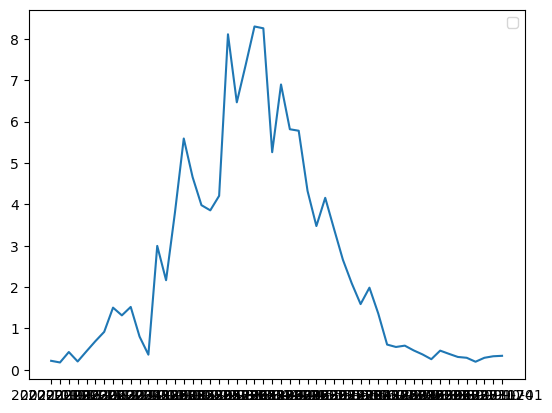

In [5]:
geocode = 5102637
test_year = 2023

df2 = pd.read_csv(f'predictions/preds_dengue_{geocode}_{test_year}.csv')

_,ax = plt.subplots()

ax.plot(df2.date, df2.pred)

ax.legend()

plt.show()

In [8]:
geocodes = [2931350, 2933307, 2302503, 3119401, 3549805,
           3541406, 1200401, 1200203, 1716109, 4113700, 4103701, 4104808,
            5201405, 5102637, 5215231]
    

In [9]:
def make_plot(df, ax, geocode, test_year, disease):
    
    df_w = df.loc[df.geocode == geocode][['casos']].resample('W-SUN').sum()
    
    df_w = prep.add_epiweek_label(df_w)
    
    df_w_casos = df_w.loc[df_w.year == test_year]

    df_m = pd.read_csv(f'predictions/preds_{disease}_{geocode}_{test_year}.csv')
    
    df_m.date = pd.to_datetime(df_m['date'])
        
    ax.plot(df_w_casos.index, df_w_casos.casos , marker='o', linestyle='', label='Data', color = 'black')

    ax.plot(df_m.date, df_m.pred, color = 'tab:orange')
    
    ax.fill_between(df_m.date, df_m.lower_95, df_m.upper_95, color = 'tab:orange', alpha = 0.1)
    
    ax.legend()
    
    ax.grid()

    ax.set_title(f'{test_year}')
    
    return 

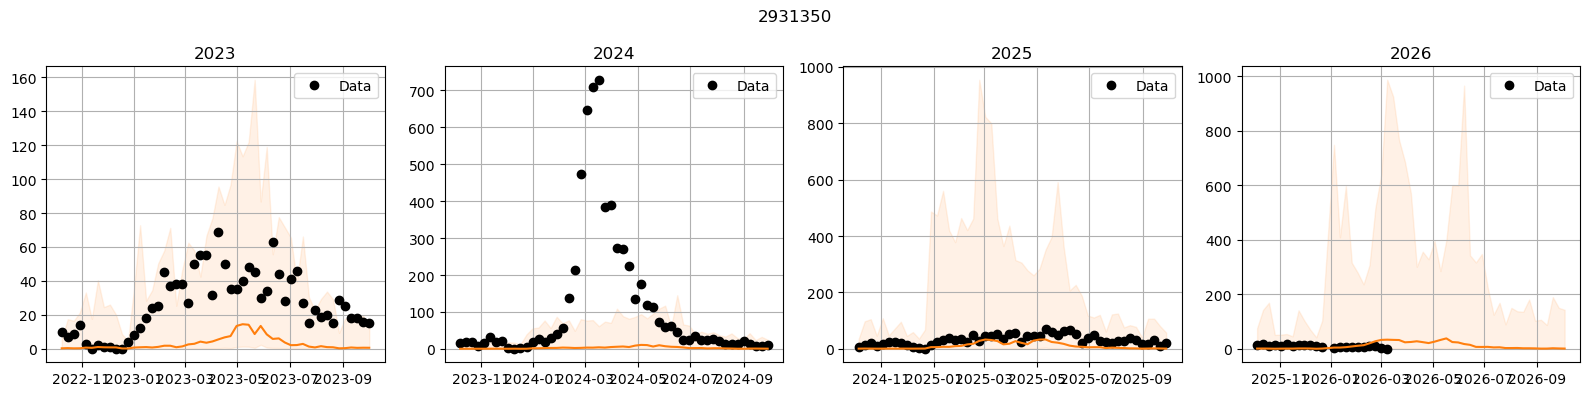

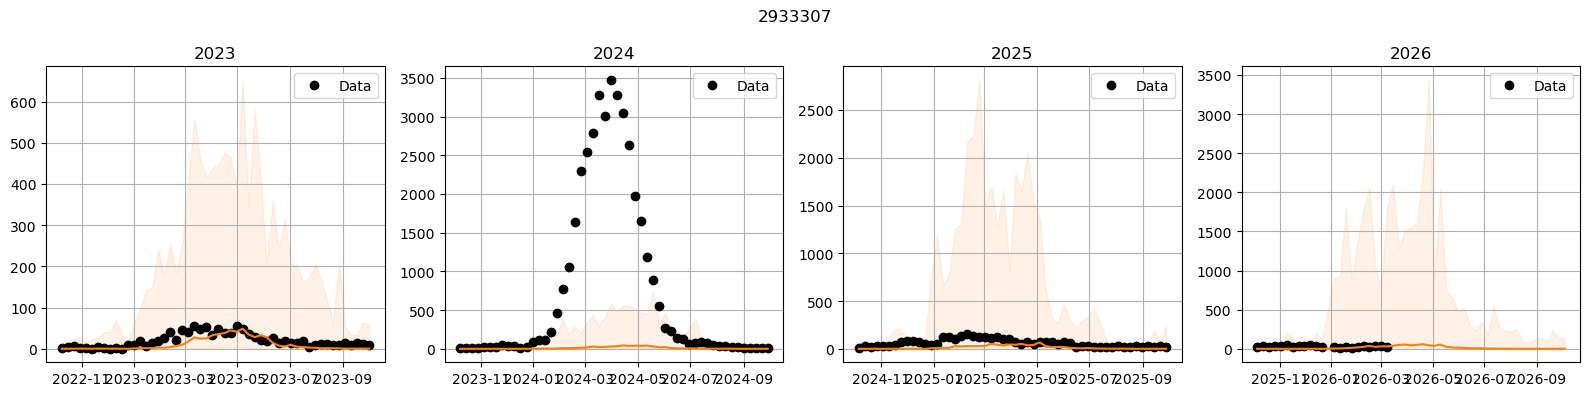

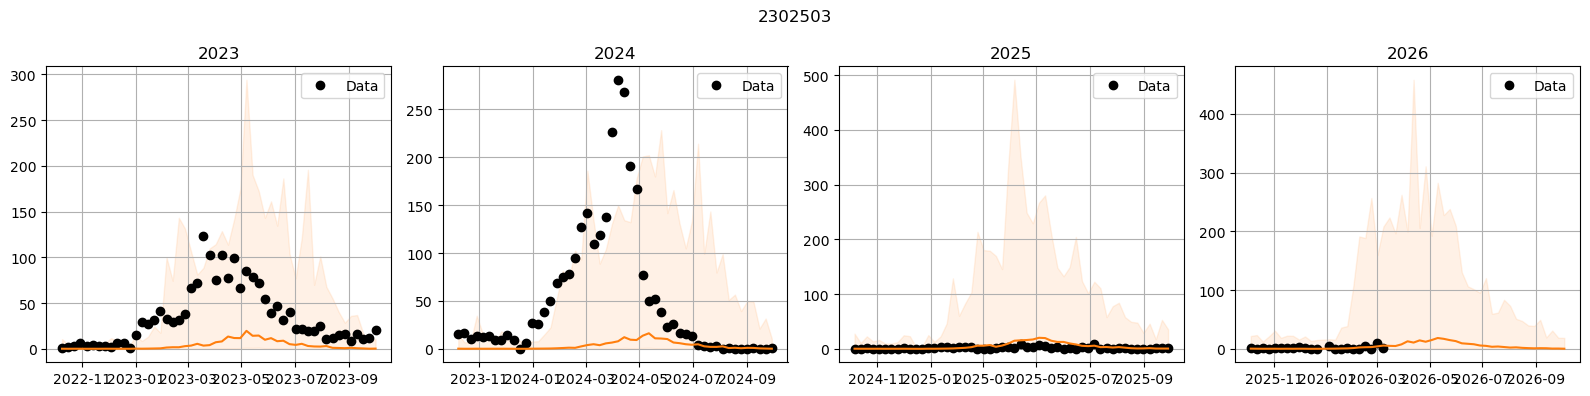

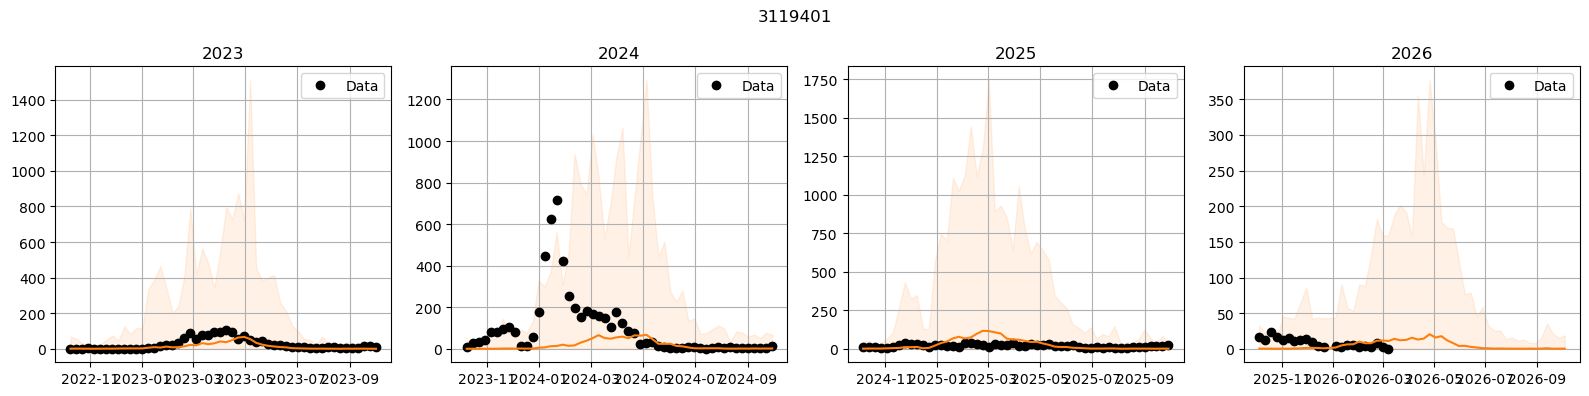

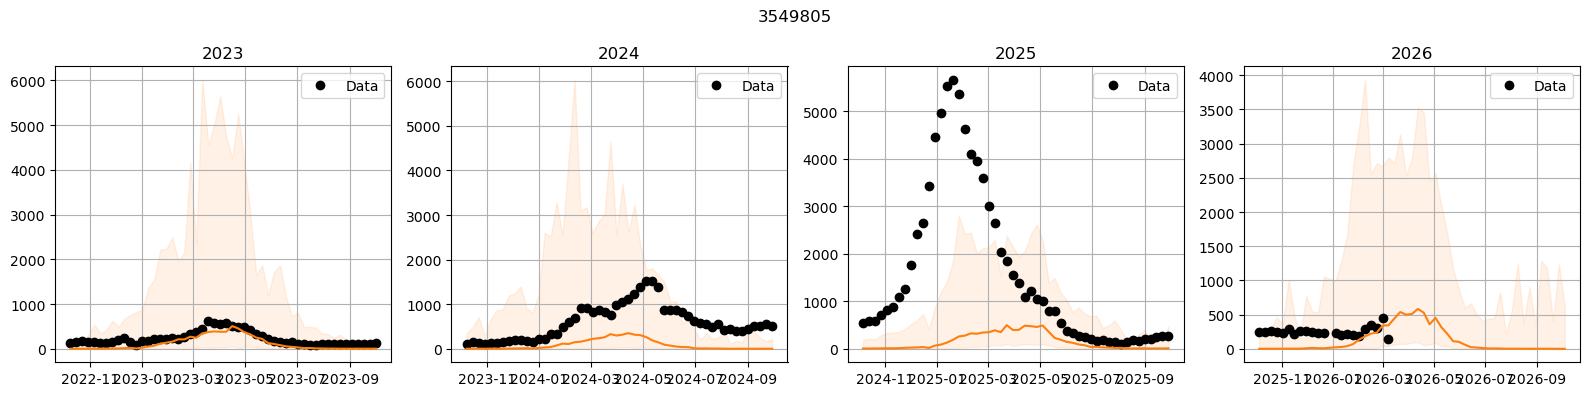

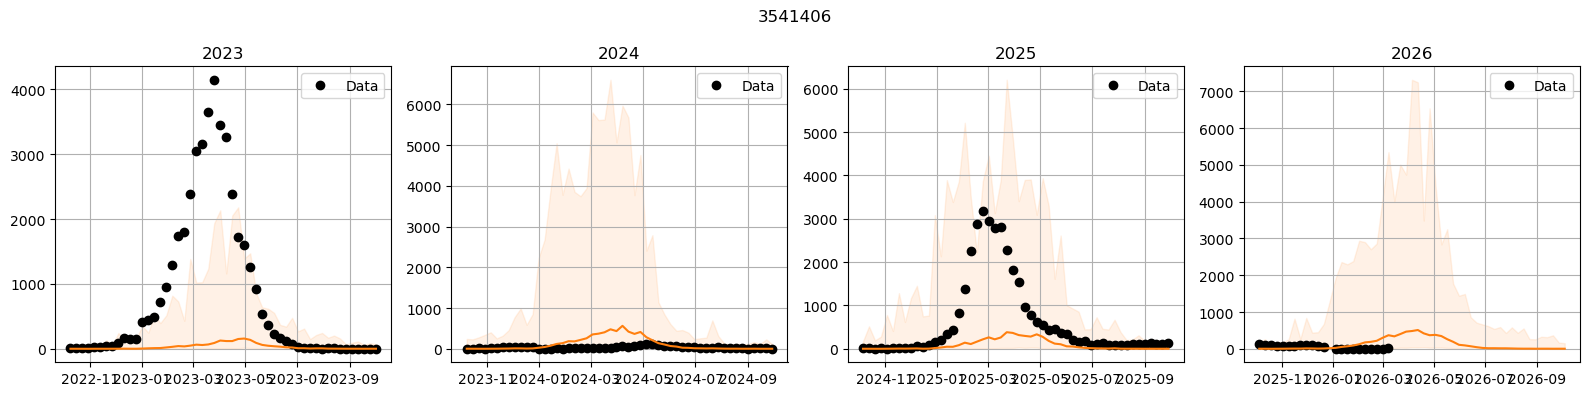

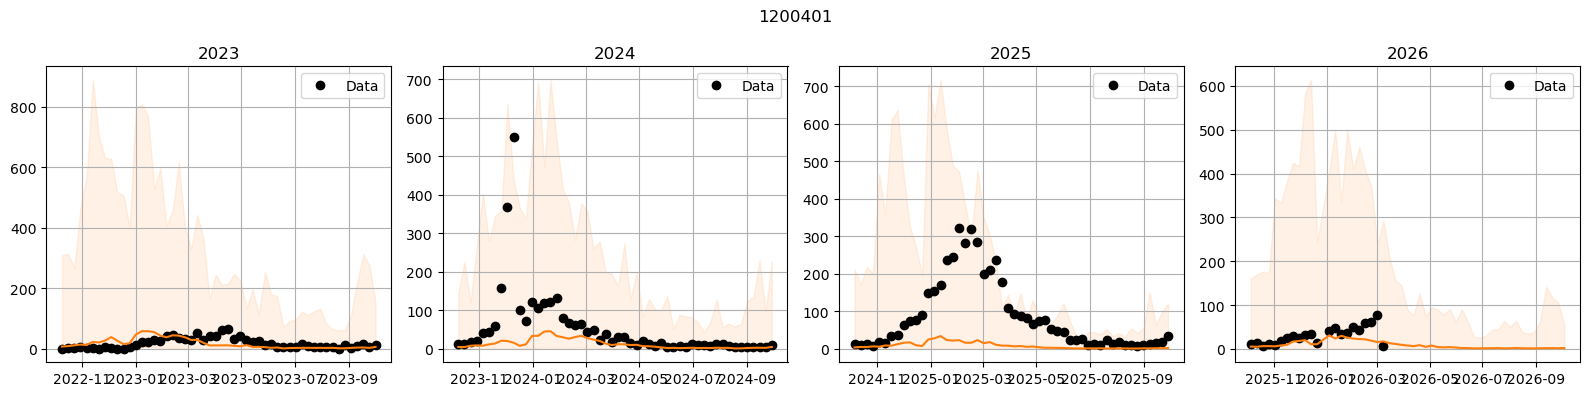

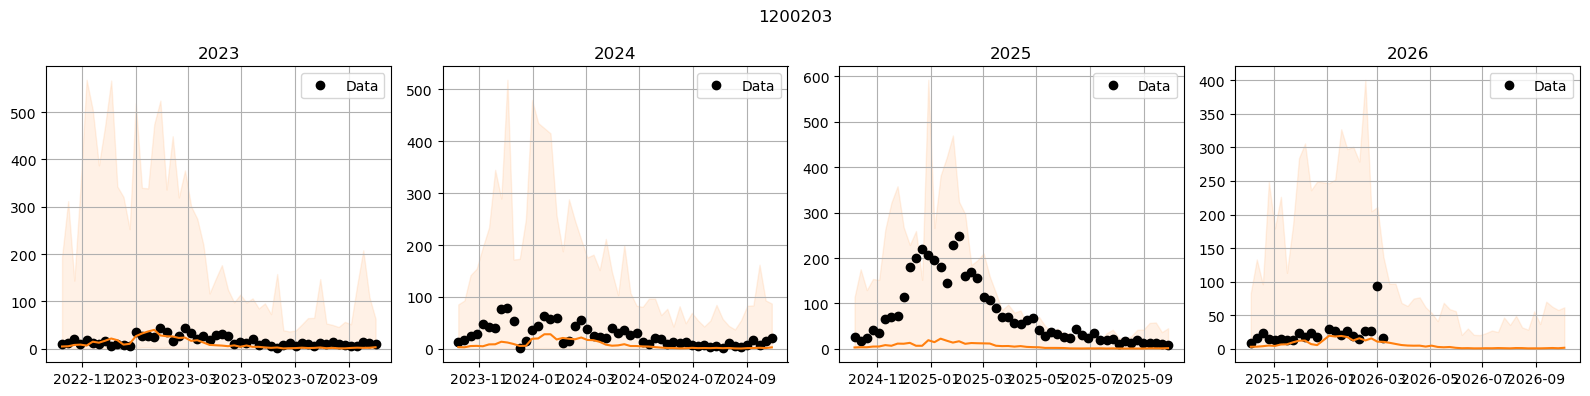

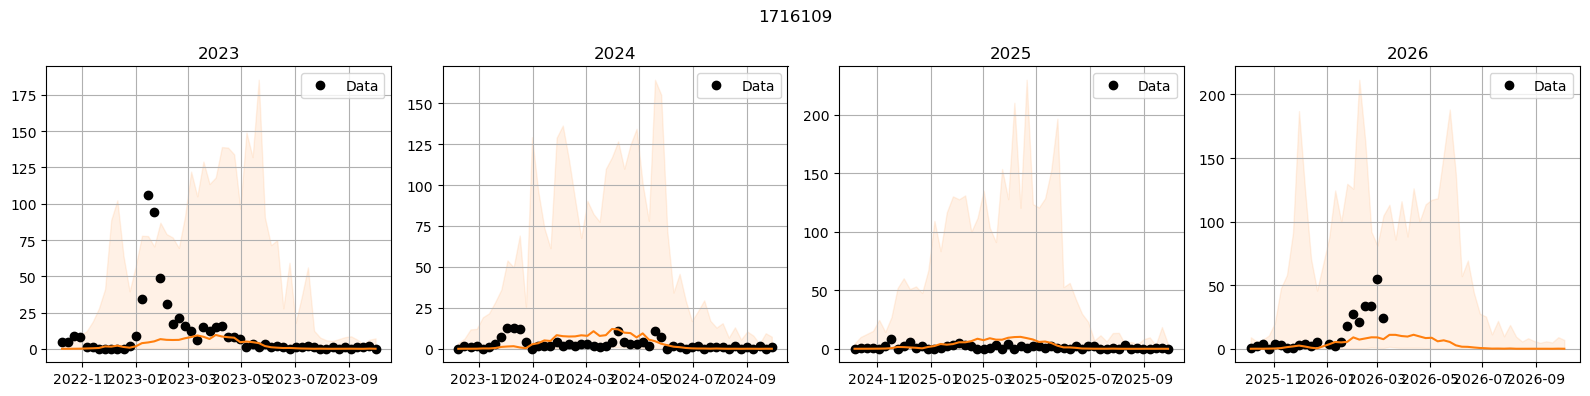

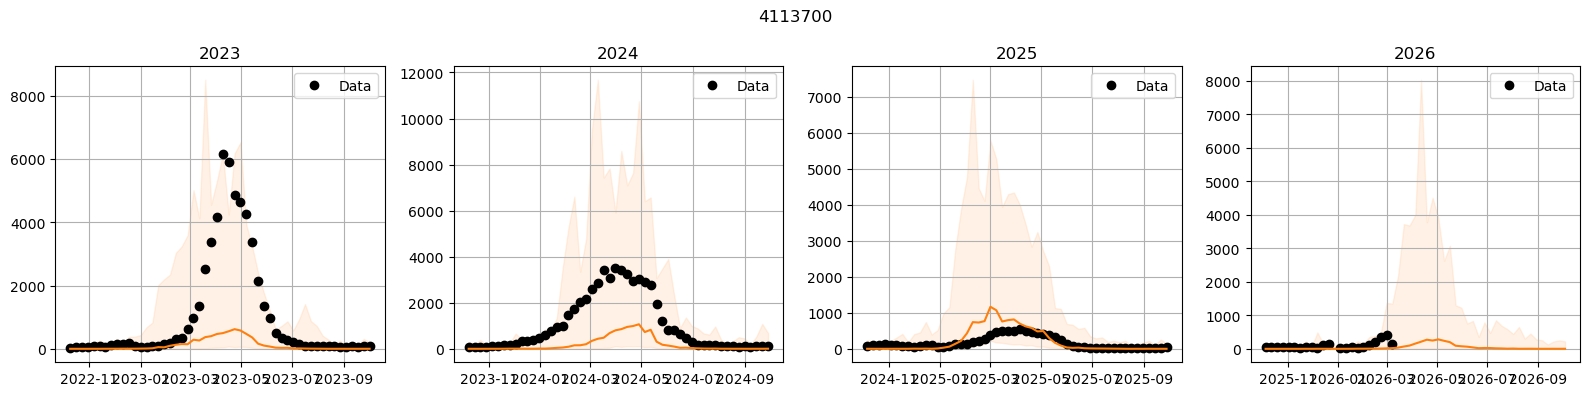

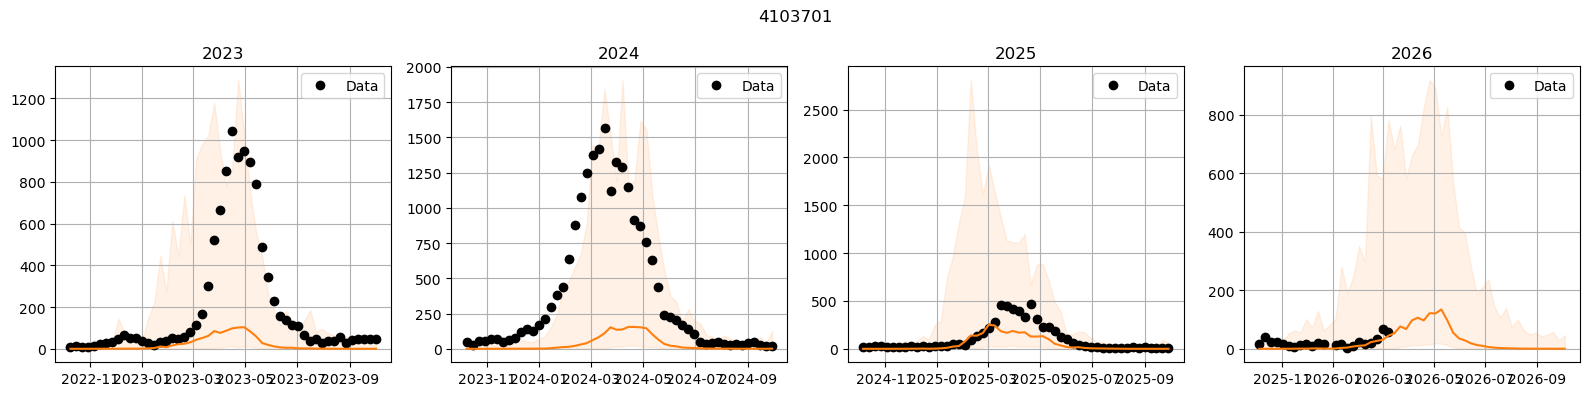

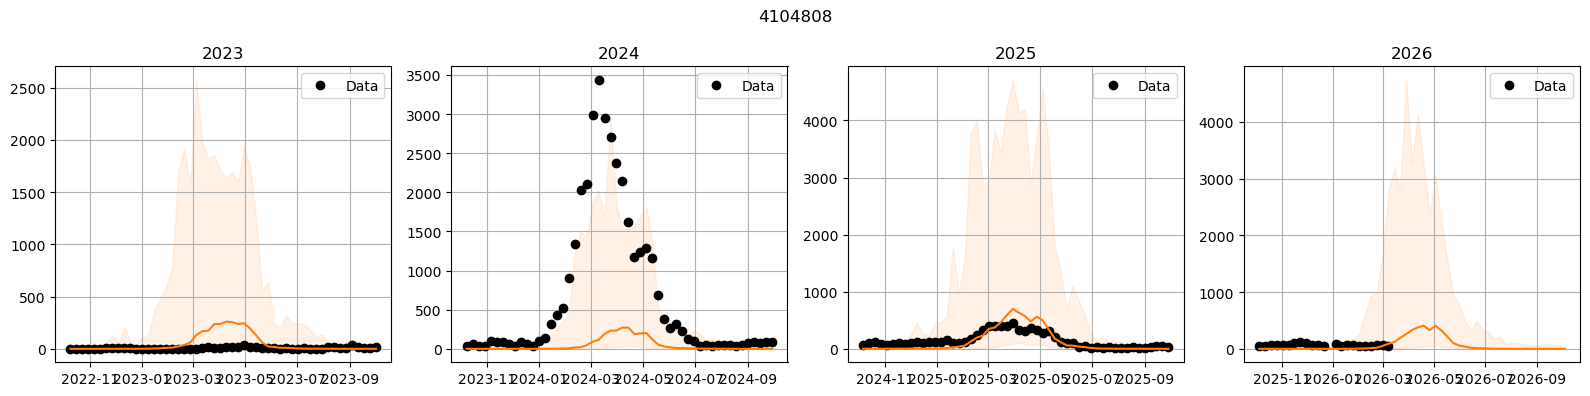

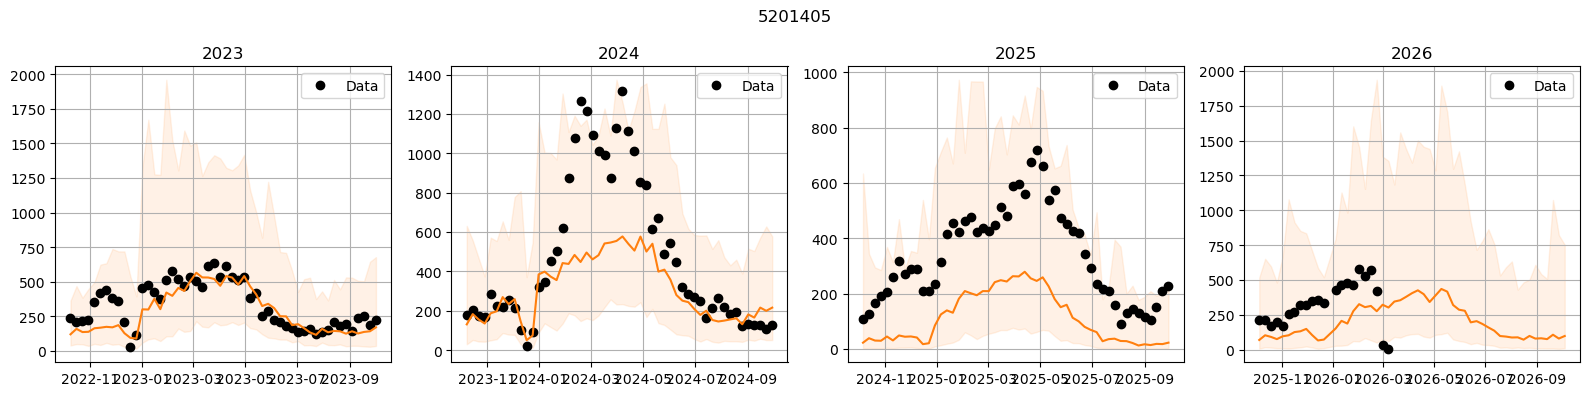

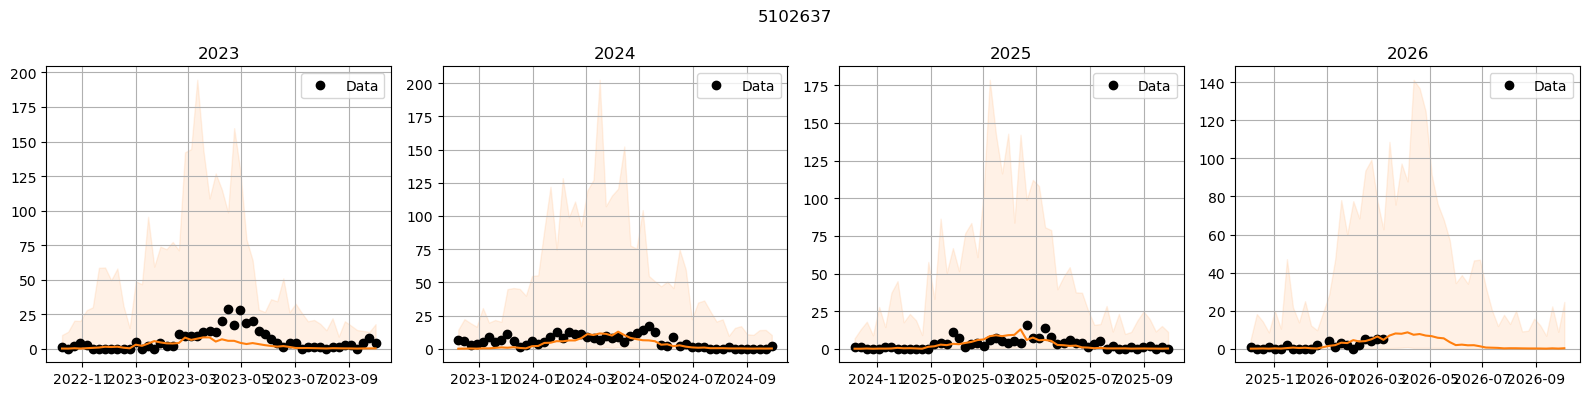

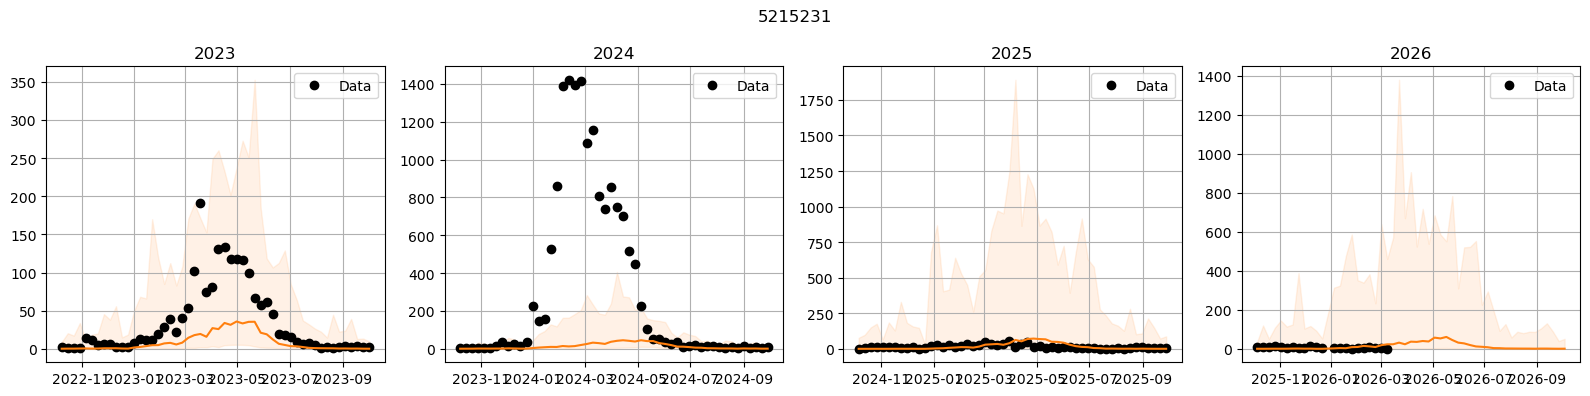

In [10]:
disease = 'dengue'

df = prep.load_cases_data(disease=disease)


for geo in geocodes:
    _,ax = plt.subplots(1,4, figsize = (16, 4))
    
    make_plot(df, ax[0], geo, test_year=2023, disease = disease)
    make_plot(df, ax[1], geo, test_year=2024, disease = disease)
    make_plot(df, ax[2], geo, test_year=2025, disease = disease)
    make_plot(df, ax[3], geo, test_year=2026, disease = disease)
    
    plt.suptitle(geo)
    plt.tight_layout()